## Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.sparse import hstack

## Load Dataset

In [3]:
df = pd.read_csv("../data/final_feature_dataset.csv")

print(df.shape)

df.head()

(3500, 16)


,ResumeID,Category,Skills,Education,Experience,Clean_Text,Text,Source,Resume_Length,Word_Count,Sentence_Count,Skill_Count,Education_Length,Experience_Length,Source_Encoded,Category_Encoded
0,REAL_0001,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...,ResumeAtlas,1495,189,1,4,3,64,0,17
1,REAL_0002,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer linkedincomi...,jared arthur maica java developer 17994568777 ...,ResumeAtlas,1686,206,1,4,3,62,0,17
2,REAL_0003,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom montgo...,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,5555,715,1,4,3,62,0,17
3,REAL_0004,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom montgo...,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,12834,1657,1,4,3,61,0,17
4,REAL_0005,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,jessica claire 100 montgomery st 10th floor xx...,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,4181,489,1,4,3,57,0,17


## Check Columns

In [4]:
print(df.columns.tolist())

['ResumeID', 'Category', 'Skills', 'Education', 'Experience', 'Clean_Text', 'Text', 'Source', 'Resume_Length', 'Word_Count', 'Sentence_Count', 'Skill_Count', 'Education_Length', 'Experience_Length', 'Source_Encoded', 'Category_Encoded']


## Select Features

In [5]:
text_feature = df["Clean_Text"]

In [6]:
numerical_features = df[
    [
        "Resume_Length",
        "Word_Count",
        "Sentence_Count",
        "Skill_Count",
        "Education_Length",
        "Experience_Length"
    ]
]

In [7]:
target = df["Category"]

## Encode Target

In [8]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(target)

print("Total Categories :", len(label_encoder.classes_))

Total Categories : 36


## TF-IDF Vectorizer

In [9]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

text_features = tfidf.fit_transform(text_feature)

print(text_features.shape)

(3500, 5000)


## Vocabulary Size

In [10]:
print("Vocabulary Size :", len(tfidf.vocabulary_))

Vocabulary Size : 5000


## Scale Numerical Features

In [11]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(numerical_features)

print(scaled_features.shape)

(3500, 6)


## Combine Features

In [12]:
X = hstack([text_features, scaled_features])

print(X.shape)

(3500, 5006)


## Save Preprocessing Objects

In [13]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Preprocessing objects saved successfully.")

Preprocessing objects saved successfully.


## Train-Test Split

In [14]:
print(type(X))

<class 'scipy.sparse._coo.coo_matrix'>


In [15]:
print(type(y))

<class 'numpy.ndarray'>


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (2800, 5006)
Testing Shape : (700, 5006)


## Import Models

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Create Model Dictionary

In [33]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        max_iter=10000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

}

## Train Function

In [34]:
def train_and_evaluate(model):

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    return accuracy

## Train All Models

In [35]:
results = {}

for model_name, model in models.items():

    accuracy = train_and_evaluate(model)

    results[model_name] = accuracy

    print(f"{model_name} : {accuracy:.4f}")

Logistic Regression : 0.8871
Linear SVM : 0.8871
Random Forest : 0.8900


## Create Results Table

In [36]:
results_df = (
    pd.DataFrame(
        list(results.items()),
        columns=["Model", "Accuracy"]
    )
    .sort_values(by="Accuracy", ascending=False)
)

results_df

,Model,Accuracy
2,Random Forest,0.890000
0,Logistic Regression,0.887143
1,Linear SVM,0.887143


## Accuracy Graph

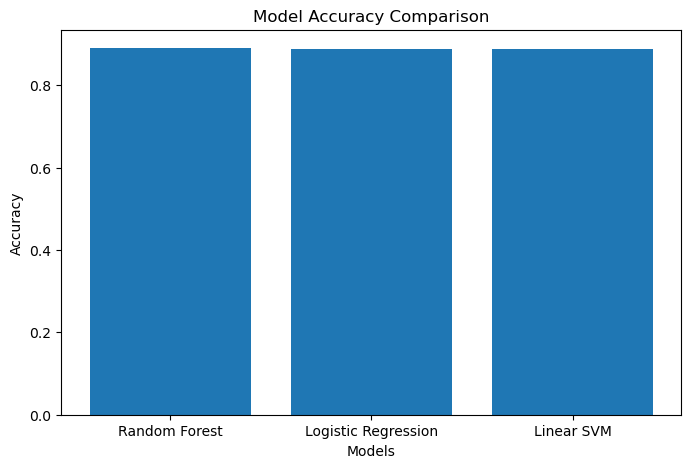

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

## Best Model

In [39]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Random Forest


## Best Model

In [40]:
best_model = models["Random Forest"]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Best Model : Random Forest")

Best Model : Random Forest


## Classification Report

In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                           precision    recall  f1-score   support

              AI Engineer       1.00      1.00      1.00        14
        Backend Developer       1.00      1.00      1.00        15
               Blockchain       1.00      0.80      0.89        10
     Blockchain Developer       1.00      1.00      1.00         6
         Business Analyst       0.88      1.00      0.94        30
           Cloud Engineer       1.00      1.00      1.00        19
    Cybersecurity Analyst       1.00      1.00      1.00        13
             Data Science       0.80      0.97      0.88        40
                 Database       1.00      0.53      0.70        30
   Database Administrator       1.00      1.00      1.00        11
                   DevOps       0.92      1.00      0.96        36
            Digital Media       0.84      0.80      0.82        20
         DotNet Developer       0.82      0.82      0.82        28
            ETL Developer       0.78      0.88      0.82     

## Confusion Matrix

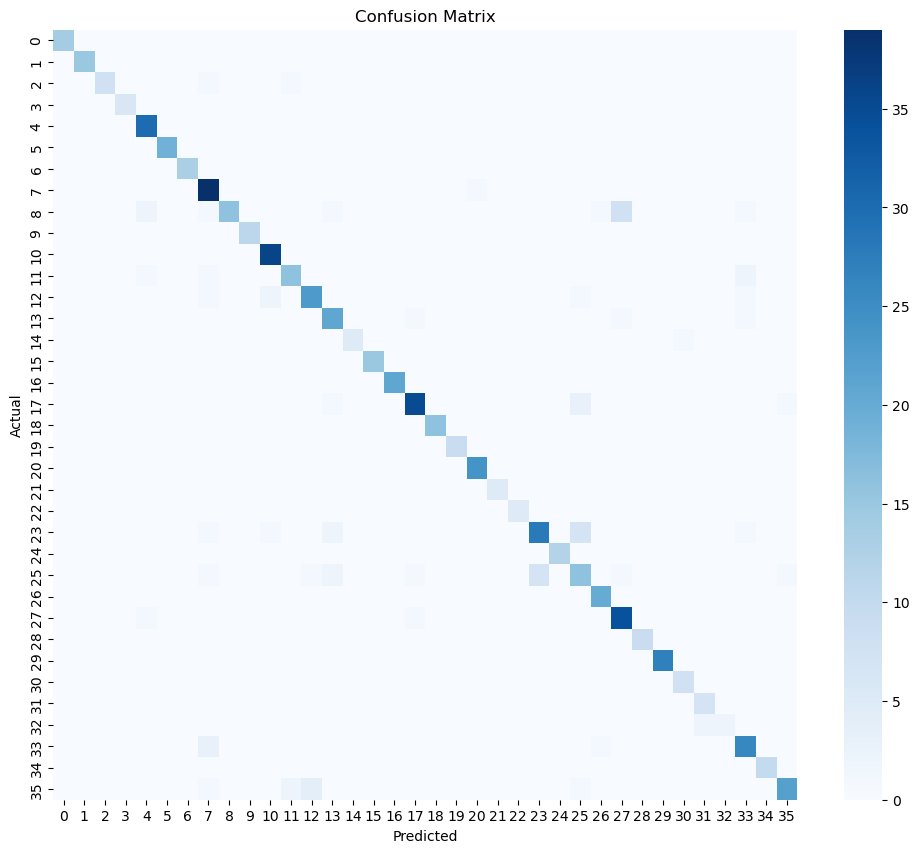

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Cross Validation

In [43]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:")

print(scores)

print()

print("Average Accuracy :", scores.mean())

Cross Validation Scores:
[0.90571429 0.88714286 0.89428571 0.88857143 0.88285714]

Average Accuracy : 0.8917142857142857


## Save Model

In [44]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/resume_classifier.pkl")

print("Model Saved Successfully")

Model Saved Successfully


## Save Results

In [45]:
results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully


## Final Summary

In [46]:
print("="*50)

print("Resume Classification Module Completed")

print()

print("Best Model :", "Random Forest")

print("Accuracy :", round(results["Random Forest"],4))

print("="*50)

Resume Classification Module Completed

Best Model : Random Forest
Accuracy : 0.89
